In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

# Шаг 1: Загрузка данных
data = pd.read_csv("../data/lb3/Wholesale_customers_data.csv")
print(data.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [2]:

# Выбор признаков для кластеризации
X = data[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].values

# Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Количество кластеров: 2, Средний силуэтный коэффициент: 0.792
Количество кластеров: 3, Средний силуэтный коэффициент: 0.265
Количество кластеров: 4, Средний силуэтный коэффициент: 0.267
Количество кластеров: 5, Средний силуэтный коэффициент: 0.240
Количество кластеров: 6, Средний силуэтный коэффициент: 0.234
Количество кластеров: 7, Средний силуэтный коэффициент: 0.244
Количество кластеров: 8, Средний силуэтный коэффициент: 0.252
Количество кластеров: 9, Средний силуэтный коэффициент: 0.272
Количество кластеров: 10, Средний силуэтный коэффициент: 0.280


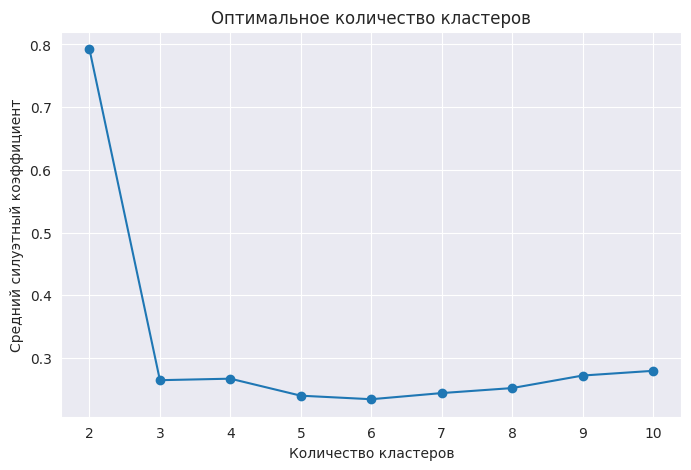

In [3]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for n_clusters in range(2, 11):
    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = agg_clustering.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, labels)
    silhouette_scores.append(silhouette_avg)
    print(f'Количество кластеров: {n_clusters}, Средний силуэтный коэффициент: {silhouette_avg:.3f}')

# Построение графика зависимости силуэтного коэффициента от количества кластеров
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Количество кластеров')
plt.ylabel('Средний силуэтный коэффициент')
plt.title('Оптимальное количество кластеров')
plt.show()

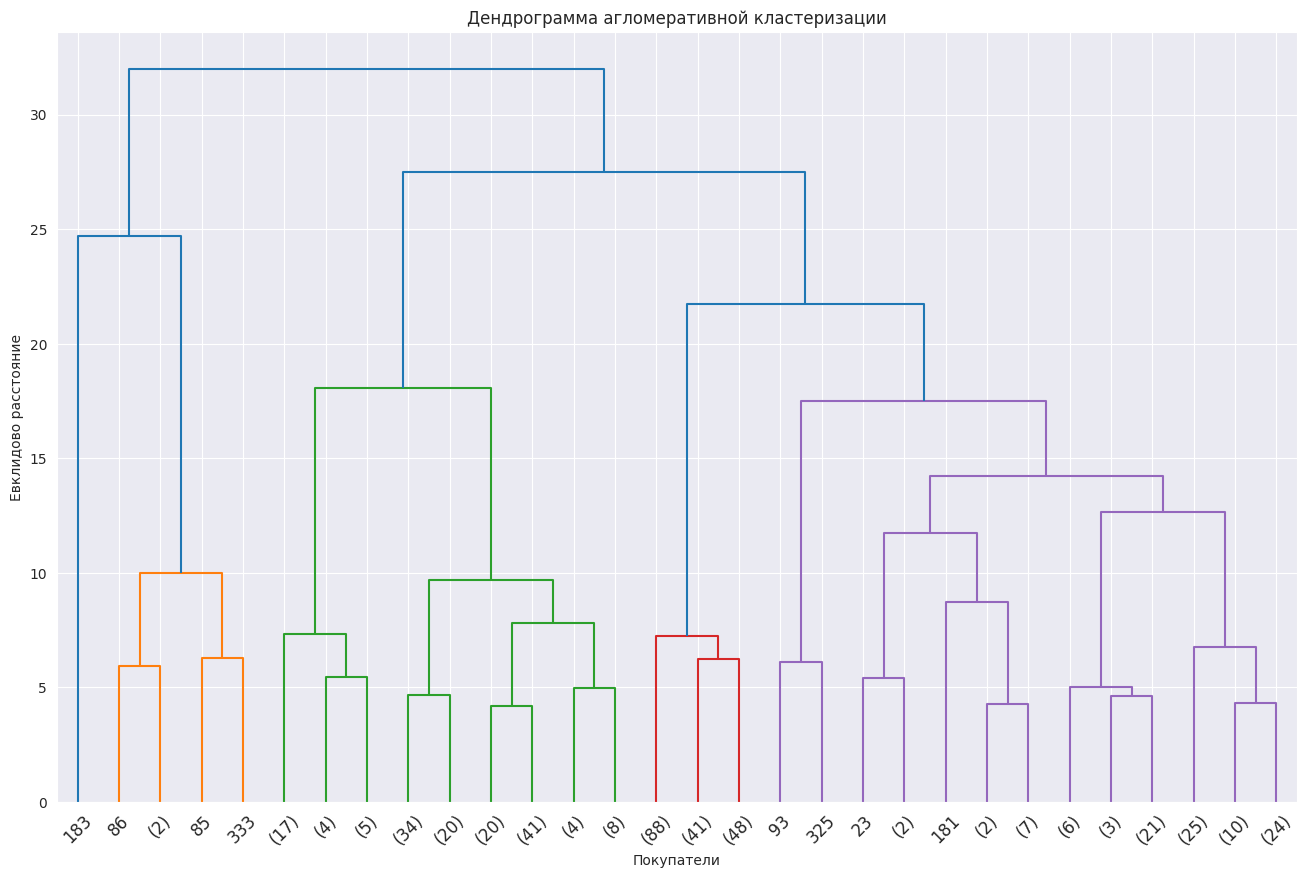

In [4]:

# Шаг 2: Построение дендрограммы для определения числа кластеров
plt.figure(figsize=(16, 10))
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=12, color_threshold=20)
plt.title('Дендрограмма агломеративной кластеризации')
plt.xlabel('Покупатели')
plt.ylabel('Евклидово расстояние')
plt.show()


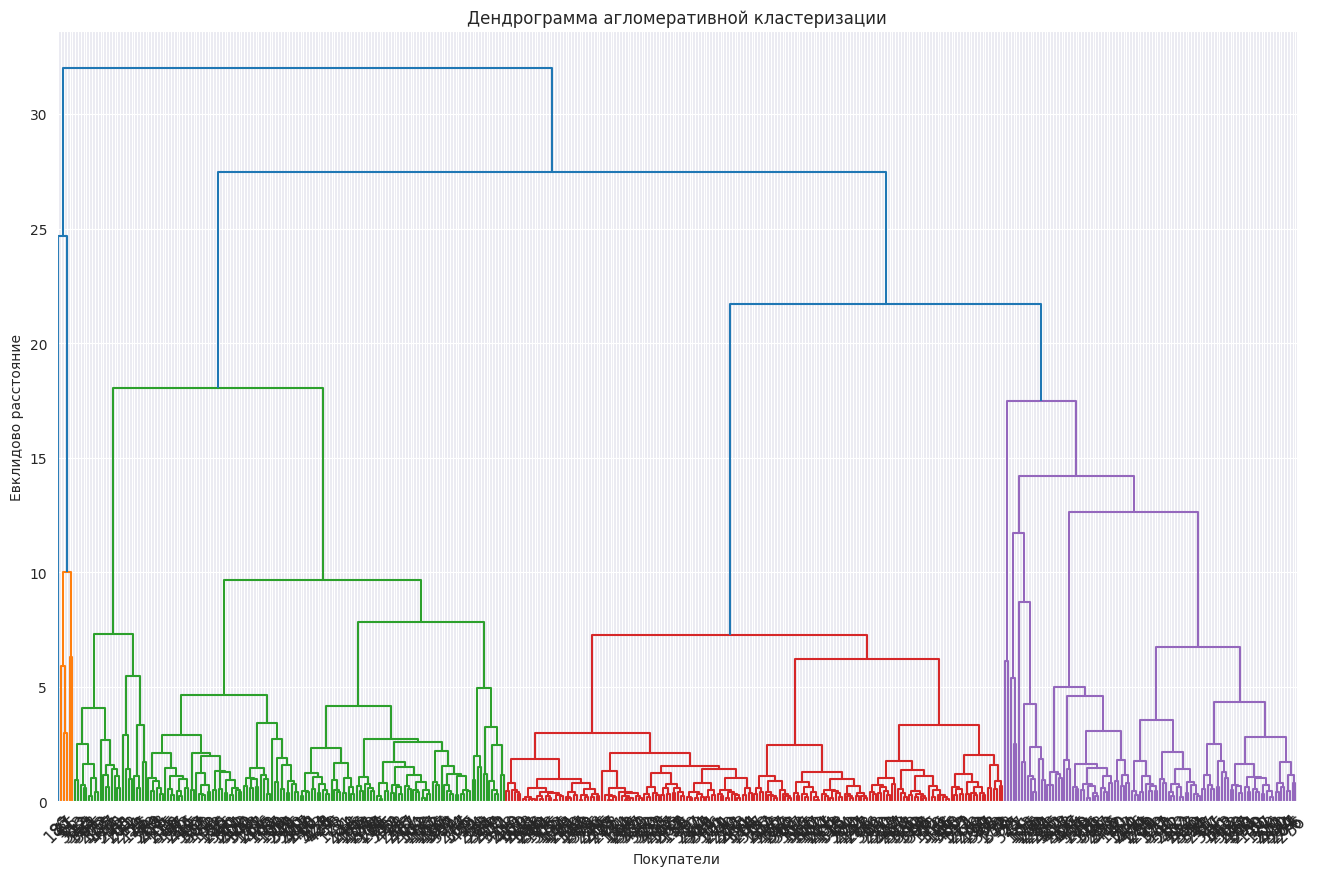

In [5]:
plt.figure(figsize=(16, 10))
Z = linkage(X_scaled, method='ward')
dendrogram(Z, leaf_rotation=45, leaf_font_size=12, color_threshold=20)
plt.title('Дендрограмма агломеративной кластеризации')
plt.xlabel('Покупатели')
plt.ylabel('Евклидово расстояние')
plt.show()


In [6]:
# Дендрограмма агломеративной кластеризации демонстрирует иерархическую структуру объединения точек на основе расстояния между ними. Высота соединений на графике отражает евклидовое расстояние между кластерами на каждом этапе объединения. Чем выше точка слияния, тем больше различие между объединяемыми кластерами. На графике четко выделяются несколько крупных ветвей, что указывает на наличие основных кластеров, которые можно выделить на определённом уровне разреза. Цветные ветви указывают на различные группы, сформированные на ранних этапах кластеризации, которые затем объединяются в более крупные кластеры. Используя метод Ward, алгоритм минимизирует внутрикластерную дисперсию, что позволяет получить компактные и плотные группы. Таким образом, дендрограмма наглядно демонстрирует вложенную структуру данных и позволяет выбрать оптимальное количество кластеров, ориентируясь на высоту слияния и визуально различимые группы.

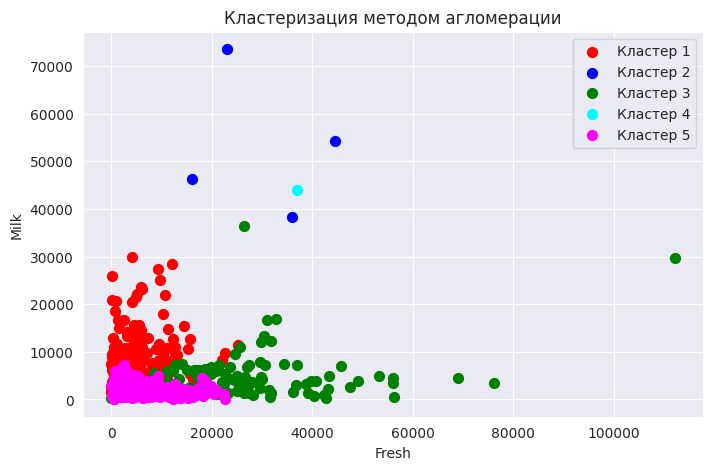

In [7]:

# Шаг 3: Агломеративная кластеризация с выбранным числом кластеров (например, 4)
n_clusters = 5
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels = agg_clustering.fit_predict(X_scaled)

# Шаг 4: Визуализация кластеров
plt.figure(figsize=(8, 5))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for cluster in np.unique(labels):
    cluster_points = X[labels == cluster]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=50, color=colors[cluster], label=f'Кластер {cluster+1}')

plt.xlabel('Fresh')
plt.ylabel('Milk')
plt.title('Кластеризация методом агломерации')
plt.legend()
plt.show()

In [8]:
# График демонстрирует результаты агломеративной кластеризации с выделением четырех кластеров. Каждая группа отображена разным цветом:
#
# Кластер 1 (красный): Наиболее многочисленный кластер с низкими значениями по показателям Fresh и Milk. Содержит преимущественно клиентов с небольшими закупками свежих продуктов и молочных товаров.
#
# Кластер 2 (синий): Содержит несколько клиентов с высокими значениями по обоим параметрам, представляя собой редкие случаи оптовых закупок крупных объемов.
#
# Кластер 3 (зеленый): Средние показатели по объему покупок, особенно молочных продуктов, формируя группу клиентов с умеренными закупками.
#
# Кластер 4 (бирюзовый): Клиенты с высокими закупками молочных продуктов и относительно низкими значениями Fresh, представляя группу с более специализированными покупками.
#
# Распределение показывает значительную плотность кластера 1 и относительно разреженные группы других кластеров. Это указывает на то, что большая часть клиентов делает небольшие закупки свежих продуктов и молока, в то время как клиенты с крупными закупками составляют редкое исключение.

In [9]:
# Датасет Wholesale Customers представляет собой данные о покупках оптовых клиентов, которые включают шесть категорий продуктов: Fresh, Milk, Grocery, Frozen, Detergents_Paper и Delicassen. Кластеризация методом агломерации позволила выявить основные группы клиентов с похожими паттернами закупок. Основные выводы по результатам кластеризации:
#
# Основная масса клиентов делает небольшие закупки по большинству категорий, формируя плотный базовый кластер.
#
# Группы с высокими закупками молочных продуктов и свежих товаров выделяются в отдельные редкие кластеры.
#
# Плотность распределения клиентов указывает на то, что высокообъемные закупки характерны лишь для небольшого числа покупателей.
# Результаты кластеризации позволяют сегментировать клиентов на группы с разными объемами закупок и потребительскими привычками. Это дает возможность:
#
# Разработать маркетинговые стратегии с учетом потребностей каждой группы клиентов.
#
# Оптимизировать складские и логистические процессы, сосредотачивая внимание на продуктах с высоким спросом в ключевых кластерах.
#
# Идентифицировать аномальные закупки, что может помочь в выявлении оптовых заказов или особых потребностей.
#
# Таким образом, кластеризация позволяет получить глубокое понимание структуры данных и потребностей клиентов, что ценно для принятия управленческих решений и разработки персонализированных предложений.

In [10]:

# Шаг 5: Оценка качества кластеризации
silhouette_avg = silhouette_score(X_scaled, labels)
print(f'Средний силуэтный коэффициент: {silhouette_avg:.3f}')

Средний силуэтный коэффициент: 0.240


In [11]:
# Средний силуэтный коэффициент для агломеративной кластеризации составил 0.267. Это значение указывает на низкое качество кластеризации, что свидетельствует о значительном перекрытии кластеров или наличии точек на границе между кластерами.
#
# Почему коэффициент низкий:
# Неплотные и разреженные кластеры: Некоторые группы содержат малое количество точек с большими различиями между объектами, что снижает средний силуэтный коэффициент.
#
# Перекрытие кластеров: Основной кластер с низкими значениями Fresh и Milk пересекается с кластерами средней плотности, что создаёт неопределённость в принадлежности точек.
#
# Высокая вариативность данных: Некоторые клиенты делают закупки в сильно отличающихся объемах, из-за чего кластеры становятся неоднородными.
#
# Что можно улучшить:
# Изменить параметры агломеративной кластеризации, например, использовать другие методы связи (например, "average" или "complete" вместо "ward").
#
# Применить предварительное уменьшение размерности (например, с помощью PCA), чтобы устранить избыточные признаки и улучшить отделимость кластеров.
#
# Использовать другие методы кластеризации, такие как DBSCAN или GMM, чтобы учесть плотность и перекрытие точек.
# Таким образом, значение силуэтного коэффициента 0.267 свидетельствует о том, что выделенные кластеры являются слабо различимыми и перекрывающимися, что может указывать на необходимость пересмотра подхода к сегментации данных или использования других алгоритмов кластеризации.
